In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

In [9]:
df=pd.read_csv("/content/Year-wise Details of Road Accidents, Persons Killed and Injured from 1970 to 2024.csv")
df.head()

,Years,Total Number of Road Accidents (in numbers),Total Number of Persons Killed (in numbers),Total Number of Persons Injured (in numbers),Population of India (in thousands),Total Number of Registered Motor Vehicles (in thousands),Road Length (in kms),Number of Accidents per Lakh Population,Number of Accidents per Ten Thousand Vehicles,Number of Accidents per Ten Thousand Kms of Roads,Number of Persons Killed Per Lakh Population,Number of Persons Killed Per Ten Thousand Vehicles,Number of Persons Killed per Ten Thousand Kms of Roads,Number of Persons Injured per Lakh Population,Number of Persons Injured Per Ten Thousand Vehicles,Number of Persons Injured Per Ten Thousand Kms of Roads
0,1970,114100.0,14500.0,70100.0,539000.0,1401.0,914979.0,21.2,814.4,959.8,2.7,103.5,122.0,13.0,500.4,589.7
1,1980,153200.0,24000.0,109100.0,673000.0,4521.0,1485421.0,22.8,338.9,1026.9,3.6,53.1,160.9,16.2,241.3,731.3
2,1990,282600.0,54100.0,244100.0,835000.0,19152.0,1983867.0,33.8,147.6,1424.5,6.5,28.2,272.7,29.2,127.5,1230.4
3,1995,351999.0,70781.0,323200.0,924359.0,30295.0,2975035.0,38.1,116.2,1183.2,7.7,23.4,237.9,35.0,106.7,1086.4
4,1996,371204.0,74665.0,369502.0,941579.0,33786.0,3202515.0,39.4,109.9,1159.1,7.9,22.1,233.1,39.2,109.4,1153.8


In [10]:
df = df[df["Years"].astype(str).str.match(r"^\d{4}$")].copy()
df["Years"] = df["Years"].astype(int)

# Convert everything else to numeric, coercing "NA"/blank to NaN
for col in df.columns:
    if col != "Years":
        df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.sort_values("Years").reset_index(drop=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33 entries, 0 to 32
Data columns (total 16 columns):
 #   Column                                                    Non-Null Count  Dtype  
---  ------                                                    --------------  -----  
 0   Years                                                     33 non-null     int64  
 1   Total Number of Road Accidents (in numbers)               33 non-null     float64
 2   Total Number of Persons Killed (in numbers)               33 non-null     float64
 3   Total Number of Persons Injured (in numbers)              33 non-null     float64
 4   Population of India (in thousands)                        33 non-null     float64
 5   Total Number of Registered Motor Vehicles (in thousands)  31 non-null     float64
 6   Road Length (in kms)                                      31 non-null     float64
 7   Number of Accidents per Lakh Population                   33 non-null     float64
 8   Number of Accidents pe

<bound method NDFrame.head of              Years  Total Number of Road Accidents (in numbers)  \
0             1970                                    114100.00   
1             1980                                    153200.00   
2             1990                                    282600.00   
3             1995                                    351999.00   
4             1996                                    371204.00   
5             1997                                    373671.00   
6             1998                                    385018.00   
7             1999                                    386456.00   
8             2000                                    391449.00   
9             2001                                    405637.00   
10            2002                                    407497.00   
11            2003                                    406726.00   
12            2004                                    429910.00   
13            2005                                    439255.00   
14            2006                                    460920.00   
15            2007                                    479216.00   
16            2008                                    484704.00   
17            2009                                    486384.00   
18            2010                                    499628.00   
19            2011                                    497686.00   
20            2012                                    490383.00   
21            2013                                    486476.00   
22            2014                                    489400.00   
23            2015                                    505770.00   
24            2016                                    484756.00   
25            2017                                    469242.00   
26            2018                                    470403.00   
27            2019                                    456959.00   
28            2020                                    372181.00   
29            2021                                    412432.00   
30            2022                                    461312.00   
31            2023                                    480583.00   
32            2024                                    487707.00   
33  CAGR 2014/2024                                        -0.03   

    Total Number of Persons Killed (in numbers)  \
0                                      14500.00   
1                                      24000.00   
2                                      54100.00   
3                                      70781.00   
4                                      74665.00   
5                                      76977.00   
6                                      79919.00   
7                                      81966.00   
8                                      78911.00   
9                                      80888.00   
10                                     84674.00   
11                                     85998.00   
12                                     92618.00   
13                                     94968.00   
14                                    105749.00   
15                                    114444.00   
16                                    119860.00   
17                                    125660.00   
18                                    134513.00   
19                                    142485.00   
20                                    138258.00   
21                                    137572.00   
22                                    139671.00   
23                                    146555.00   
24                                    151192.00   
25                                    150003.00   
26                                    157593.00   
27                                    158984.00   
28                                    138383.00   
29                                    153972.00   
30                                    16849

In [12]:
COL_ACCIDENTS = "Total Number of Road Accidents (in numbers)"
COL_KILLED    = "Total Number of Persons Killed (in numbers)"
COL_INJURED   = "Total Number of Persons Injured (in numbers)"
COL_VEHICLES  = "Total Number of Registered Motor Vehicles (in thousands)"
COL_ACC_RATE  = "Number of Accidents per Lakh Population"
COL_KILL_RATE = "Number of Persons Killed Per Lakh Population"
COL_ACC_PER_VEH = "Number of Accidents per Ten Thousand Vehicles"


def millions_formatter(x, pos):
    return f"{x/1e5:.0f}L" if x >= 1e5 else f"{x:,.0f}"

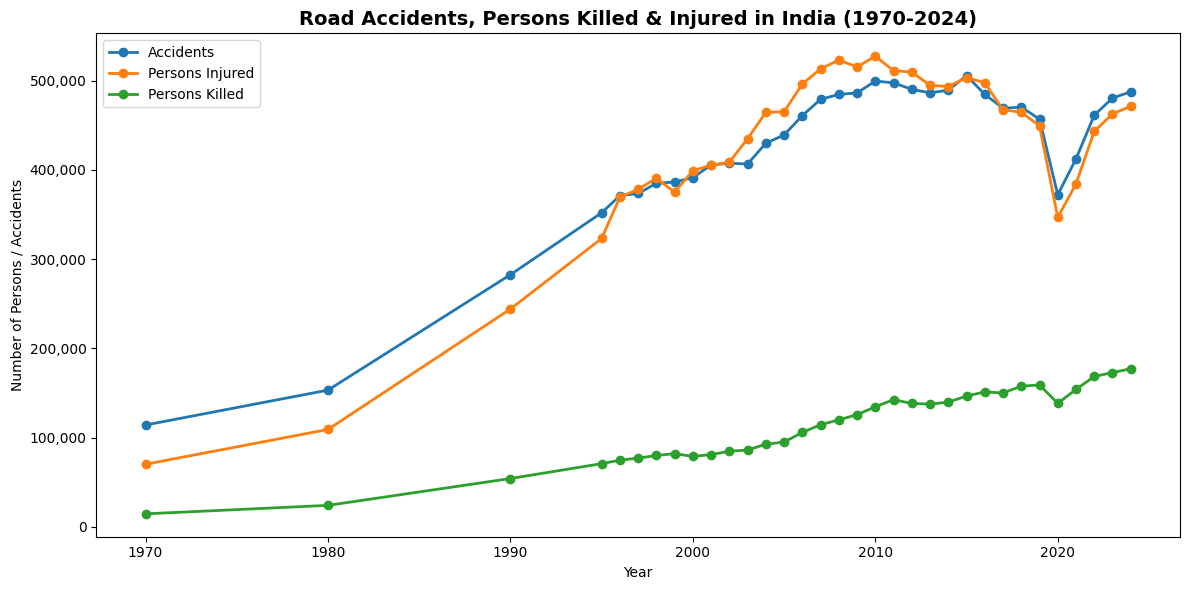

In [19]:
import matplotlib.ticker as mticker
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(df["Years"], df[COL_ACCIDENTS], marker="o", label="Accidents", linewidth=2)
ax.plot(df["Years"], df[COL_INJURED], marker="o", label="Persons Injured", linewidth=2)
ax.plot(df["Years"], df[COL_KILLED], marker="o", label="Persons Killed", linewidth=2)
ax.set_title("Road Accidents, Persons Killed & Injured in India (1970-2024)", fontsize=14, weight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("Number of Persons / Accidents")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.legend()
fig.tight_layout()
plt.show()

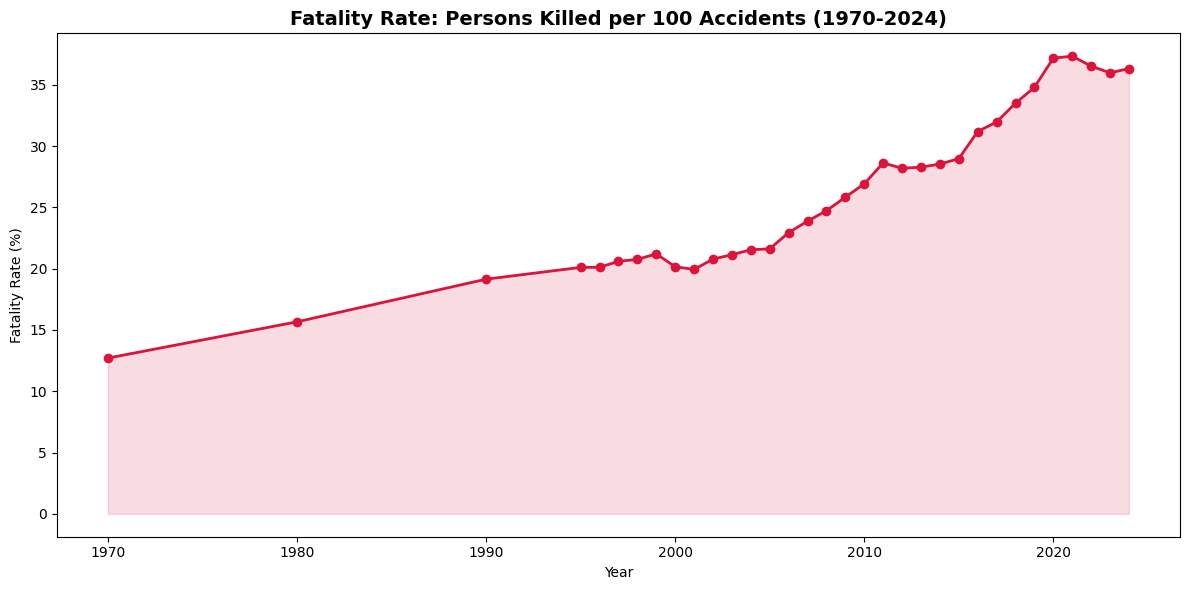

In [14]:
df["Fatality Rate (%)"] = df[COL_KILLED] / df[COL_ACCIDENTS] * 100

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(df["Years"], df["Fatality Rate (%)"], color="crimson", marker="o", linewidth=2)
ax.fill_between(df["Years"], df["Fatality Rate (%)"], alpha=0.15, color="crimson")
ax.set_title("Fatality Rate: Persons Killed per 100 Accidents (1970-2024)", fontsize=14, weight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("Fatality Rate (%)")
fig.tight_layout()
plt.show()

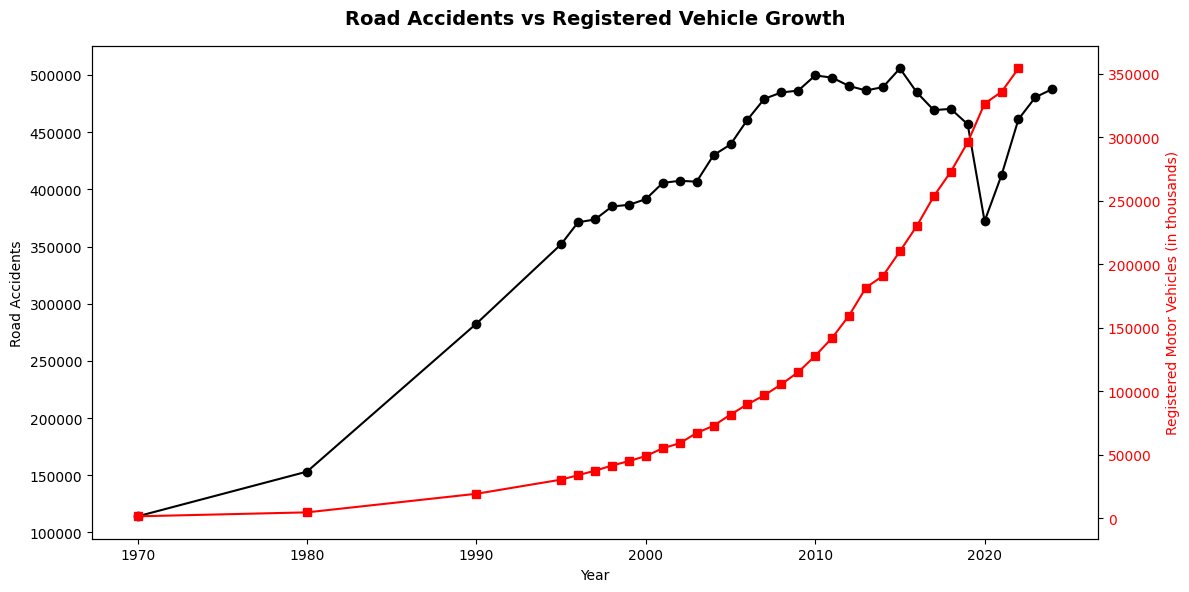

In [18]:
fig, ax1 = plt.subplots(figsize=(12, 6))
color1, color2 = "black", "red"

ax1.plot(df["Years"], df[COL_ACCIDENTS], color=color1, marker="o", label="Road Accidents")
ax1.set_xlabel("Year")
ax1.set_ylabel("Road Accidents", color=color1)
ax1.tick_params(axis="y", labelcolor=color1)

ax2 = ax1.twinx()
ax2.plot(df["Years"], df[COL_VEHICLES], color=color2, marker="s", label="Registered Vehicles (000s)")
ax2.set_ylabel("Registered Motor Vehicles (in thousands)", color=color2)
ax2.tick_params(axis="y", labelcolor=color2)

fig.suptitle("Road Accidents vs Registered Vehicle Growth", fontsize=14, weight="bold")
fig.tight_layout()
plt.show()

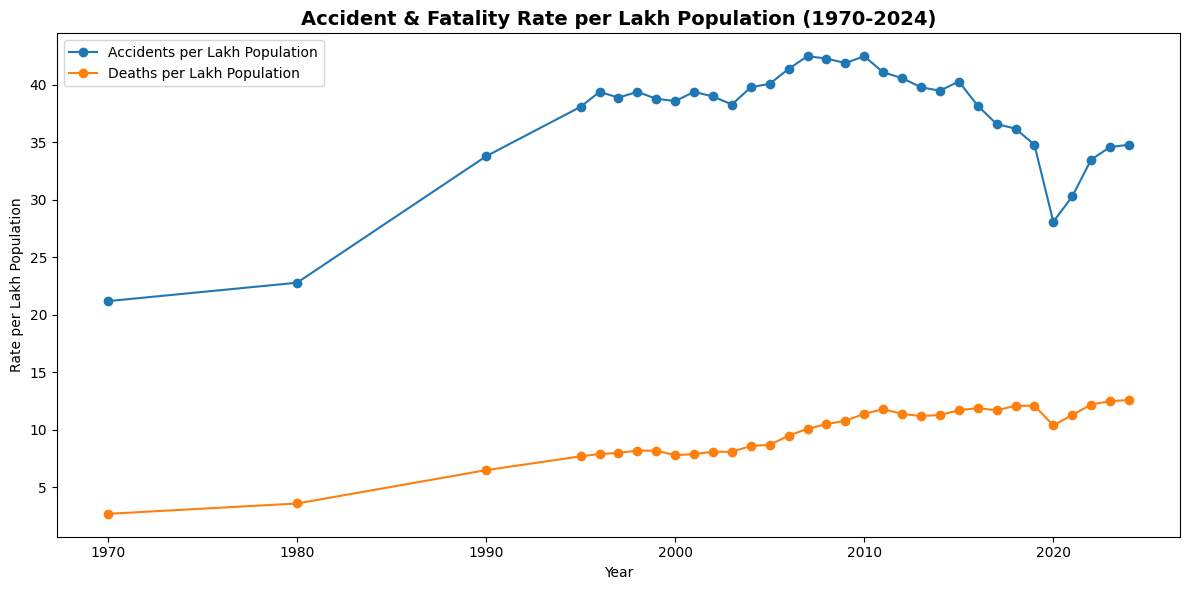

In [16]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(df["Years"], df[COL_ACC_RATE], marker="o", label="Accidents per Lakh Population")
ax.plot(df["Years"], df[COL_KILL_RATE], marker="o", label="Deaths per Lakh Population")
ax.set_title("Accident & Fatality Rate per Lakh Population (1970-2024)", fontsize=14, weight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("Rate per Lakh Population")
ax.legend()
fig.tight_layout()
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

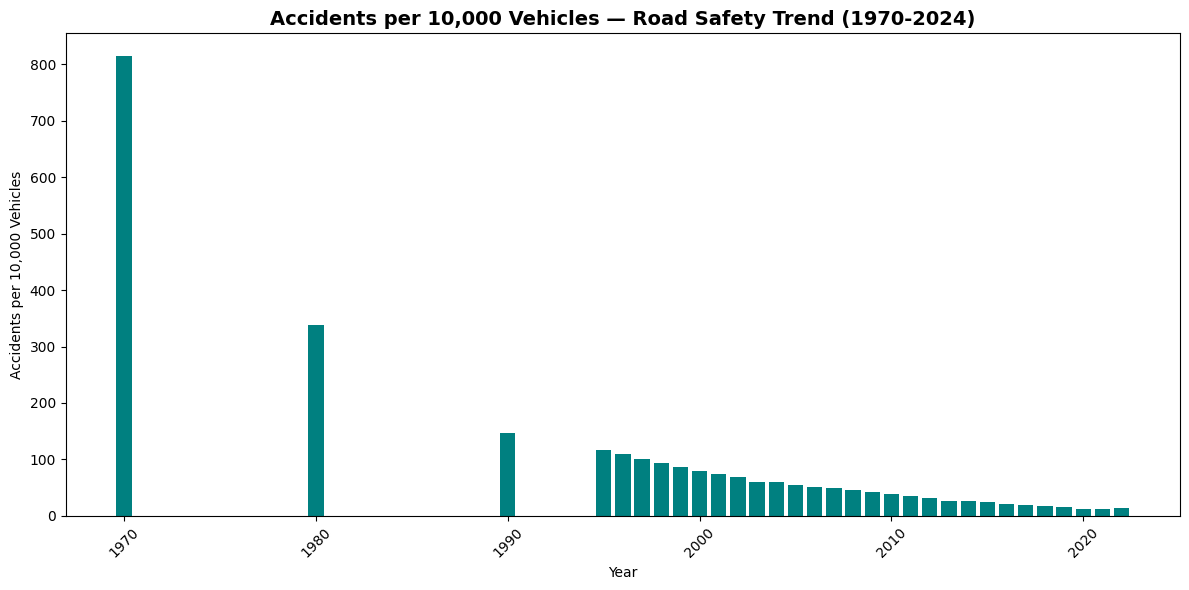

In [17]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(df["Years"], df[COL_ACC_PER_VEH], color="teal")
ax.set_title("Accidents per 10,000 Vehicles — Road Safety Trend (1970-2024)", fontsize=14, weight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("Accidents per 10,000 Vehicles")
plt.xticks(rotation=45)
fig.tight_layout()
plt.show()